# Air Quality Health Advisory Generator

This notebook implements a complete pipeline for generating air quality health advisories, from data ingestion to LSTM forecasting and LLM-based advisory generation.

## 1. Setup and Data Loading

First, we'll install and import the necessary libraries. Please upload your dataset (e.g., as a CSV file named `air_quality_data.csv`) into the Colab environment. Once uploaded, the code below will load it into a pandas DataFrame.

In [23]:
# Install necessary libraries
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn transformers requests
!pip install --upgrade google-generativeai

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from datetime import datetime, timedelta
import re

# For LLM integration
import google.generativeai as genai
from google.colab import userdata

print('Libraries installed and imported successfully.')

Libraries installed and imported successfully.


### 1.1 Load Dataset

**Action Required:** Please upload your dataset file (e.g., `air_quality_data.csv`) to your Colab environment using the file icon on the left panel before running this cell.

I will attempt to load a CSV file named `air_quality_data.csv`. If your file has a different name or format, please modify `file_path` accordingly.

In [24]:
import pandas as pd # Ensure pandas is imported

# --- Configuration Parameters (Editable) ---
FILE_PATH = 'Bangalore_AQI_Dataset.csv' # @param {type:"string"}
DATE_COLUMN_CANDIDATES = ['Date', 'date', 'datetime', 'timestamp', 'Time', 'time'] # @param
LOCATION_COLUMN_CANDIDATES = ['City', 'Location', 'location', 'station', 'site', 'Site ID', 'Station Name'] # @param
AQI_COLUMN_CANDIDATES = ['AQI', 'aqi', 'Air Quality Index'] # @param
POLLUTANT_COLUMN_CANDIDATES = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Ozone', 'NOx', 'NO'] # @param

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Dataset '{FILE_PATH}' loaded successfully. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{FILE_PATH}' not found. Please upload your dataset file to the Colab environment.")
    df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    df = None

Dataset 'Bangalore_AQI_Dataset.csv' loaded successfully. Shape: (2556, 9)


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Bangalore,01-01-2018,68,37.4,73.44,56.44,77.52,0.71,64.6
1,Bangalore,02-01-2018,76,41.8,82.08,63.08,86.64,0.80,72.2
2,Bangalore,03-01-2018,70,38.5,75.60,58.10,79.80,0.74,66.5
3,Bangalore,04-01-2018,78,42.9,84.24,64.74,88.92,0.82,74.1
4,Bangalore,05-01-2018,82,45.1,88.56,68.06,93.48,0.86,77.9


### 1.2 Automatic Column Identification

This section attempts to automatically identify the date/time, location, AQI, and pollutant columns based on common naming conventions. Please review the identified columns and adjust the `identified_columns` dictionary if necessary, especially if your column names are unusual.

In [25]:
if df is not None:
    identified_columns = {}

    # Helper function to find a column from candidates
    def find_column(df_columns, candidates):
        for cand in candidates:
            if cand in df_columns:
                return cand
        return None

    # Identify Date/Time column
    identified_columns['date'] = find_column(df.columns, DATE_COLUMN_CANDIDATES)

    # Identify Location column
    identified_columns['location'] = find_column(df.columns, LOCATION_COLUMN_CANDIDATES)
    # Robustly check for 'City' if not found by candidates (e.g., if LOCATION_COLUMN_CANDIDATES was updated after first run)
    if not identified_columns['location'] and 'City' in df.columns:
        identified_columns['location'] = 'City'

    # Identify AQI column
    identified_columns['aqi'] = find_column(df.columns, AQI_COLUMN_CANDIDATES)

    # Identify Pollutant columns
    identified_columns['pollutants'] = []
    for pollutant_cand in POLLUTANT_COLUMN_CANDIDATES:
        if pollutant_cand in df.columns:
            identified_columns['pollutants'].append(pollutant_cand)

    print("--- Identified Columns ---")
    for key, value in identified_columns.items():
        if value:
            if isinstance(value, list):
                print(f"{key.replace('_', ' ').title()}: {', '.join(value)}")
            else:
                print(f"{key.replace('_', ' ').title()}: {value}")
        else:
            print(f"Warning: Could not identify {key.replace('_', ' ').lower()} column. Please manually specify if needed.")

    if not identified_columns['date']:
        print("Error: No date/time column identified. Please ensure your dataset has a recognizable date/time column.")
    if not identified_columns['aqi'] and not identified_columns['pollutants']:
        print("Error: Neither AQI nor any pollutant columns identified. Cannot proceed without air quality data.")

    # Assign identified columns to variables for easier access
    DATE_COL = identified_columns.get('date')
    LOCATION_COL = identified_columns.get('location')
    AQI_COL = identified_columns.get('aqi')
    POLLUTANT_COLS = identified_columns.get('pollutants', [])
else:
    DATE_COL = None
    LOCATION_COL = None
    AQI_COL = None
    POLLUTANT_COLS = []
    print("Skipping column identification as dataset was not loaded.")

--- Identified Columns ---
Date: Date
Location: City
Aqi: AQI
Pollutants: PM2.5, PM10, NO2, SO2, CO, O3


## 2. Preprocessing

This section handles data cleaning, type conversion, and chronological sorting. It will also address missing values and ensure the dataset is ready for time-series analysis.

In [26]:
if df is not None and DATE_COL:
    print("--- Initial Data Info ---")
    df.info()
    print("\n--- Checking for duplicates ---")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)
    print(f"After dropping duplicates, shape: {df.shape}")

    # Convert date column to datetime and sort
    try:
        # Specify the format to match 'DD-MM-YYYY'
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], format='%d-%m-%Y')
        df.sort_values(by=DATE_COL, inplace=True)
        print(f"\n'{DATE_COL}' column converted to datetime and data sorted chronologically.")
    except Exception as e:
        print(f"Error converting '{DATE_COL}' to datetime: {e}. Please check the date column format.")
        DATE_COL = None # Invalidate if conversion fails

    # Handle missing values
    print("\n--- Handling Missing Values ---")
    missing_before = df.isnull().sum()
    print("Missing values before handling:")
    display(missing_before[missing_before > 0])

    # For time-series, forward fill is often appropriate for numerical data if gaps are small
    # and then backfill for any remaining NaNs at the beginning of the series.
    # For categorical/location, mode might be used, or it might be kept as NaN for specific analysis.
    numerical_cols = POLLUTANT_COLS + ([AQI_COL] if AQI_COL else [])
    for col in numerical_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric, coercing errors
            df[col].fillna(method='ffill', inplace=True) # Forward fill
            df[col].fillna(method='bfill', inplace=True) # Backward fill for initial NaNs

    # If location is critical and has NaNs, consider dropping rows or filling with 'Unknown'
    if LOCATION_COL and df[LOCATION_COL].isnull().any():
        print(f"Missing values in '{LOCATION_COL}'. Filling with 'Unknown'.")
        df[LOCATION_COL].fillna('Unknown', inplace=True)

    missing_after = df.isnull().sum()
    print("\nMissing values after handling:")
    display(missing_after[missing_after > 0])
    if (missing_after == 0).all():
        print("All missing values handled.")
    else:
        print("Warning: Some missing values still remain. Further investigation might be needed.")

    # Set date column as index (optional but good practice for time series)
    if DATE_COL:
        df.set_index(DATE_COL, inplace=True)
        df = df.asfreq(pd.infer_freq(df.index)) # Infer and set frequency
        if df.index.freq is None:
            print("Warning: Could not infer frequency. Resampling might be needed for consistent time steps.")
        else:
            print(f"Dataset frequency inferred and set to: {df.index.freq}")

    print("\n--- Preprocessing complete. First 5 rows of processed data: ---")
    display(df.head())
else:
    print("Skipping preprocessing as dataset was not loaded or date column not identified.")

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    2556 non-null   object 
 1   Date    2556 non-null   object 
 2   AQI     2556 non-null   int64  
 3   PM2.5   2556 non-null   float64
 4   PM10    2556 non-null   float64
 5   NO2     2556 non-null   float64
 6   SO2     2556 non-null   float64
 7   CO      2556 non-null   float64
 8   O3      2556 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 179.8+ KB

--- Checking for duplicates ---
Number of duplicate rows: 0
After dropping duplicates, shape: (2556, 9)

'Date' column converted to datetime and data sorted chronologically.

--- Handling Missing Values ---
Missing values before handling:


,0



Missing values after handling:


/tmp/ipykernel_4386/1317269371.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(method='ffill', inplace=True) # Forward fill
/tmp/ipykernel_4386/1317269371.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col].fillna(method='ffill', inplace=True) # Forward fill
/tmp/ipykernel_4386/1317269371.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inp

,0


All missing values handled.
Dataset frequency inferred and set to: <Day>

--- Preprocessing complete. First 5 rows of processed data: ---


,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3
Date,,,,,,,,
2018-01-01,Bangalore,68.0,37.4,73.44,56.44,77.52,0.71,64.6
2018-01-02,Bangalore,76.0,41.8,82.08,63.08,86.64,0.80,72.2
2018-01-03,Bangalore,70.0,38.5,75.60,58.10,79.80,0.74,66.5
2018-01-04,Bangalore,78.0,42.9,84.24,64.74,88.92,0.82,74.1
2018-01-05,Bangalore,82.0,45.1,88.56,68.06,93.48,0.86,77.9


## 3. Exploratory Data Analysis (EDA)

In this section, we will perform basic EDA to understand the distribution, trends, and correlations within the air quality data. This will include time series plots for AQI and pollutants, and a correlation matrix heatmap.

### 3.1 Summary Statistics

In [27]:
if df is not None:
    print("--- Summary Statistics for Numerical Columns ---")
    display(df[POLLUTANT_COLS + [AQI_COL]].describe())
else:
    print("Skipping summary statistics as dataframe is not available.")

--- Summary Statistics for Numerical Columns ---


,PM2.5,PM10,NO2,SO2,CO,O3,AQI
count,2556.000000,2556.000000,2556.000000,2556.000000,2556.000000,2556.000000,2556.000000
mean,40.876878,80.267324,61.686925,84.726620,0.780712,70.605516,74.321596
std,14.165722,27.816327,21.377363,29.361679,0.270381,24.468066,25.755858
min,13.200000,25.920000,19.920000,27.360000,0.250000,22.800000,24.000000
25%,29.700000,58.320000,44.820000,61.560000,0.570000,51.300000,54.000000
50%,37.950000,74.520000,57.270000,78.660000,0.720000,65.550000,69.000000
75%,50.050000,98.280000,75.530000,103.740000,0.960000,86.450000,91.000000
max,113.300000,222.480000,170.980000,234.840000,2.160000,195.700000,206.000000


### 3.2 AQI and Pollutant Trends Over Time

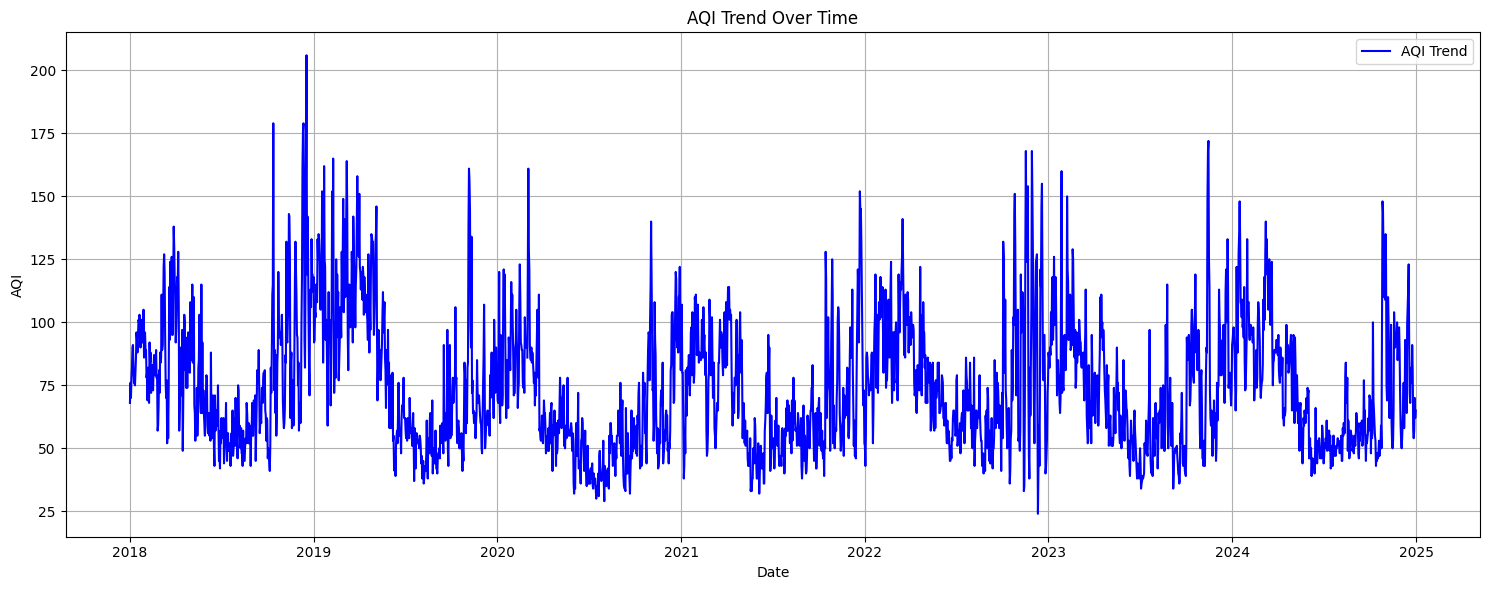

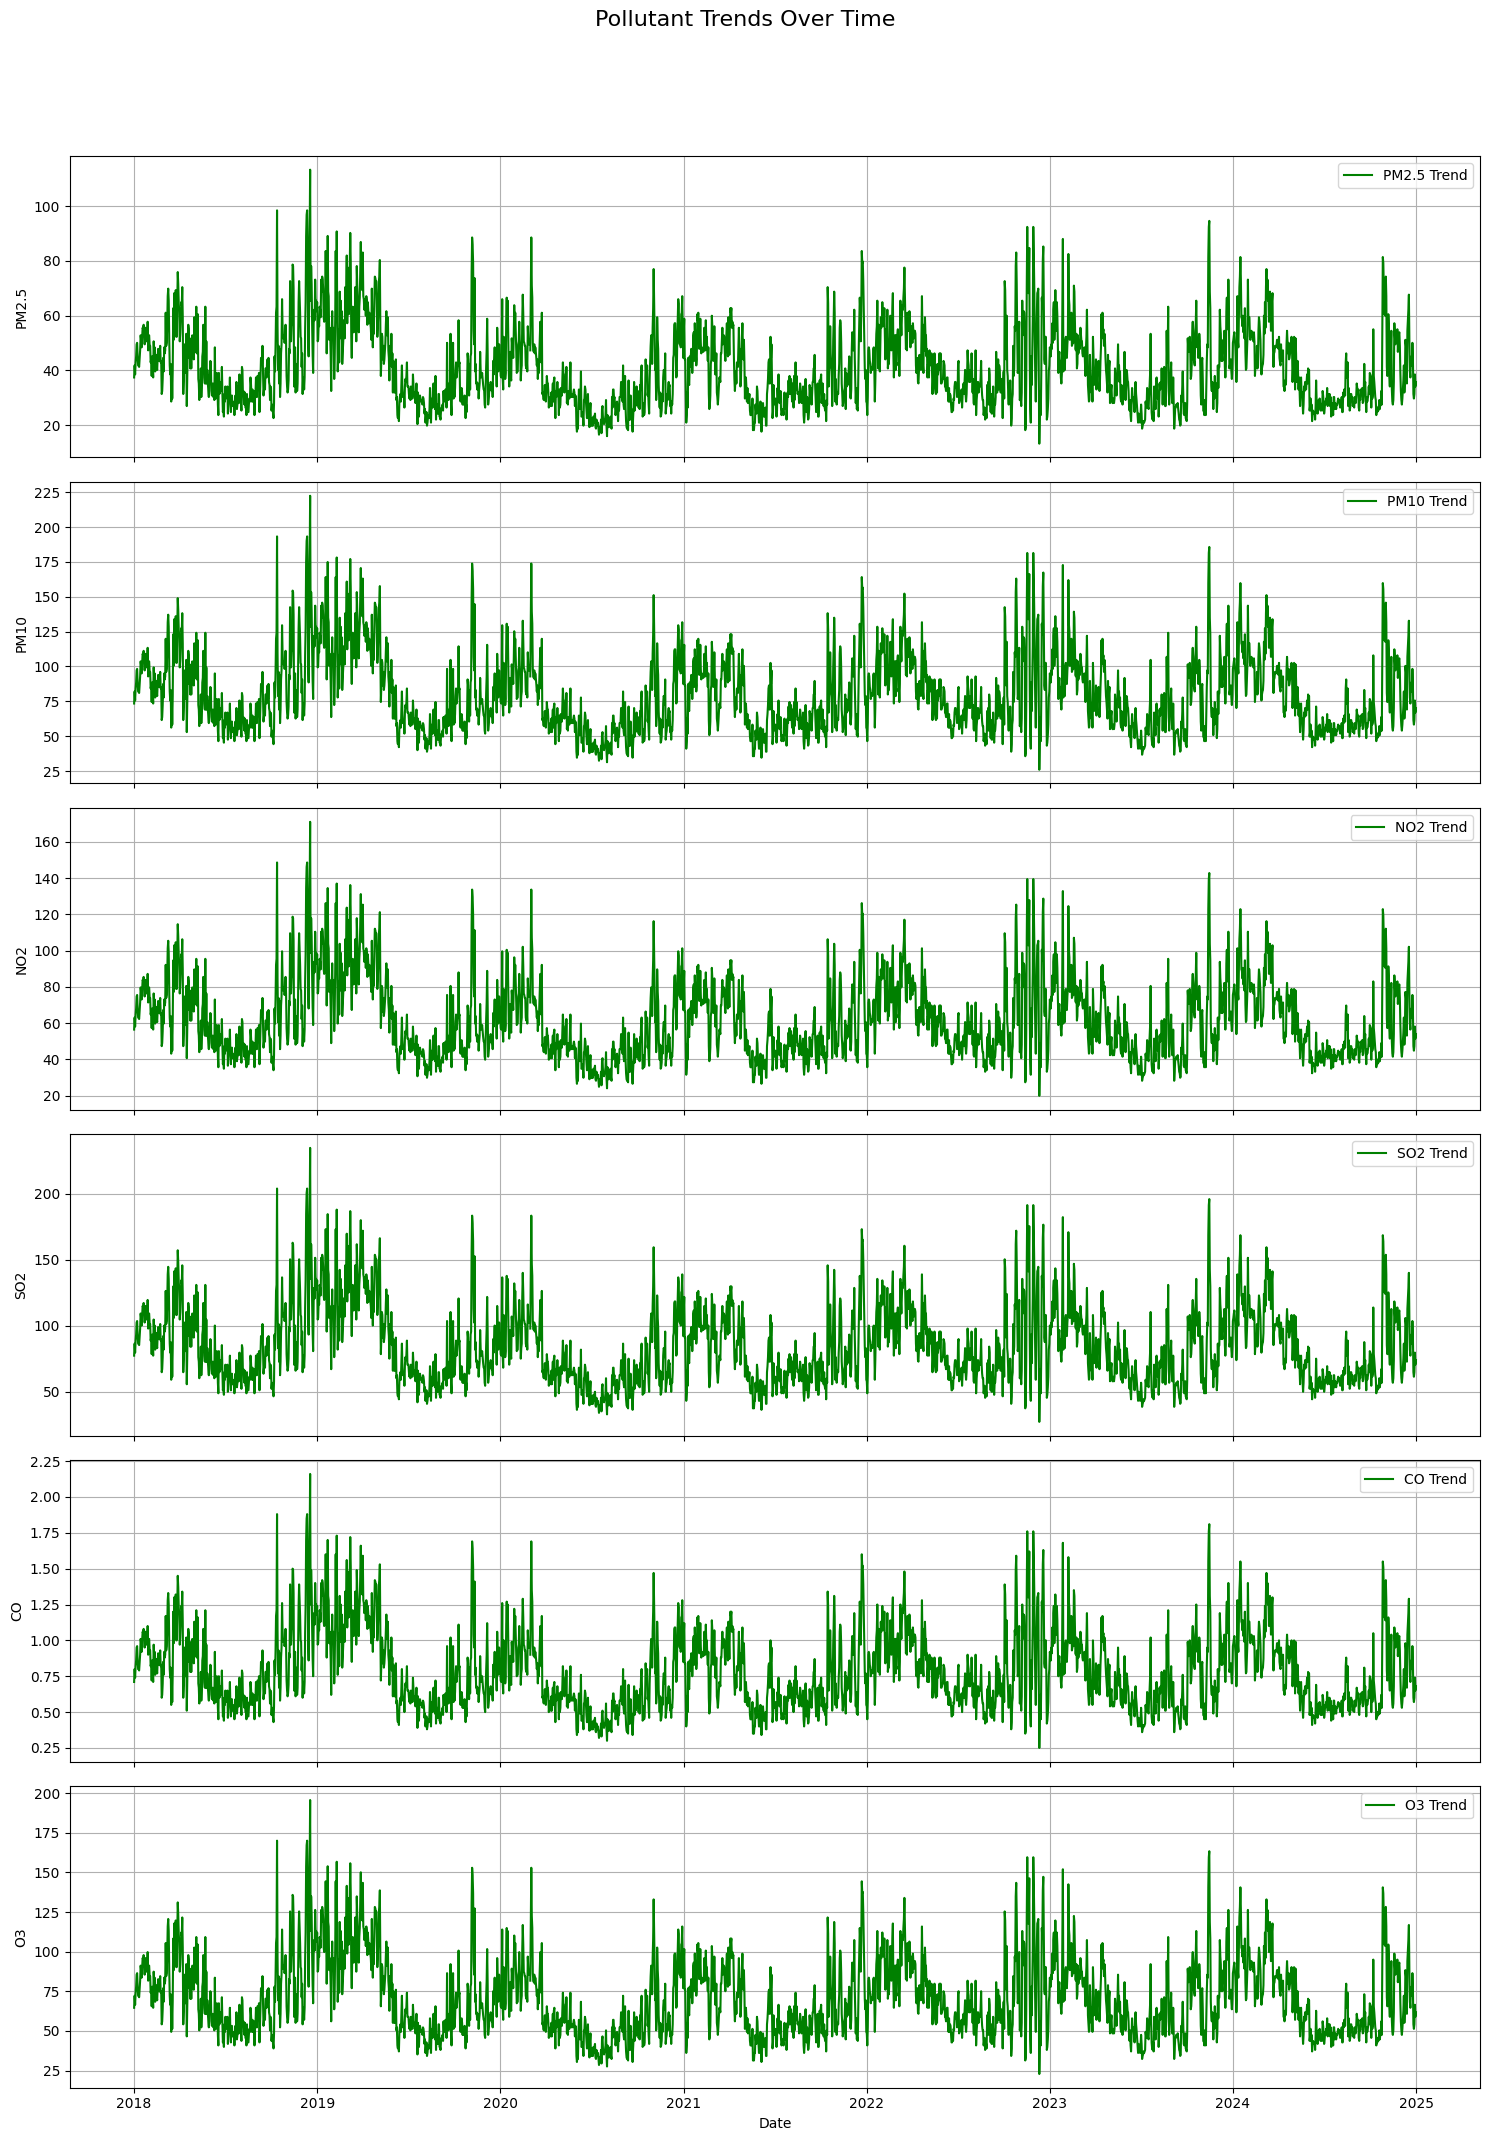

In [28]:
if df is not None and DATE_COL and AQI_COL:
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df[AQI_COL], label=f'{AQI_COL} Trend', color='blue')
    plt.title(f'{AQI_COL} Trend Over Time')
    plt.xlabel('Date')
    plt.ylabel(f'{AQI_COL}')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot trends for individual pollutants
    num_pollutants = len(POLLUTANT_COLS)
    if num_pollutants > 0:
        fig, axes = plt.subplots(num_pollutants, 1, figsize=(15, 4 * num_pollutants), sharex=True)
        if num_pollutants == 1:
            axes = [axes] # Make it iterable for consistency

        for i, col in enumerate(POLLUTANT_COLS):
            axes[i].plot(df.index, df[col], label=f'{col} Trend', color='green')
            axes[i].set_ylabel(col)
            axes[i].grid(True)
            axes[i].legend()

        axes[-1].set_xlabel('Date')
        fig.suptitle('Pollutant Trends Over Time', y=0.92, fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.88]) # Adjust layout to prevent title overlap
        plt.show()
    else:
        print("No pollutant columns identified to plot trends.")
else:
    print("Skipping trend plots as dataframe or required columns are not available.")

### 3.3 Correlation Plots

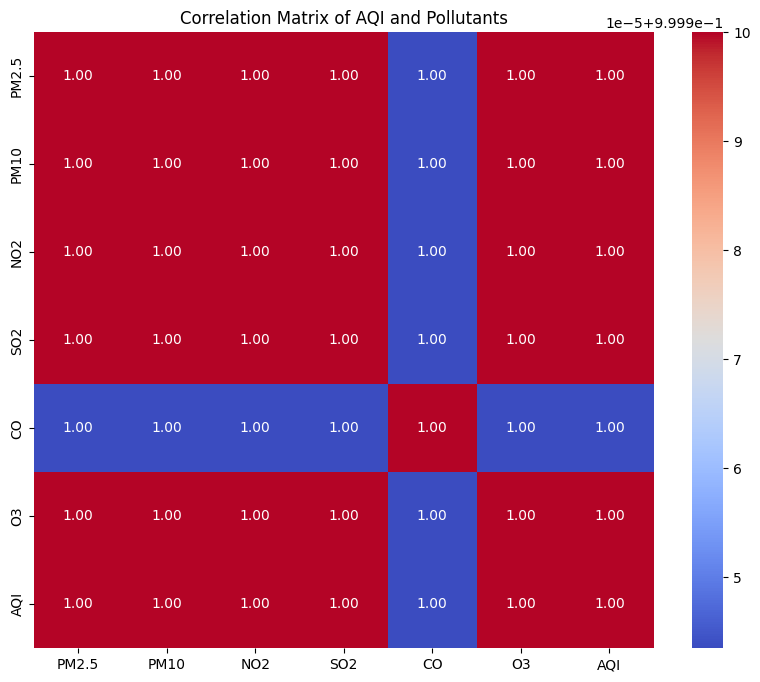

In [29]:
if df is not None and AQI_COL and POLLUTANT_COLS:
    corr_cols = POLLUTANT_COLS + [AQI_COL]
    correlation_matrix = df[corr_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of AQI and Pollutants')
    plt.show()
else:
    print("Skipping correlation plots as dataframe or required columns are not available.")

## 4. LSTM Forecasting

This section focuses on building and training a multivariate Long Short-Term Memory (LSTM) model to forecast future pollutant concentrations and AQI. We'll ensure chronological splits to prevent data leakage and evaluate the model using various metrics.

### 4.1 LSTM Configuration Parameters

These parameters control the LSTM model's architecture and training process. Feel free to adjust them based on your dataset characteristics and desired performance.

In [34]:
# --- LSTM Configuration (Editable) ---
LOOK_BACK_WINDOW = 30  # @param {type:"integer"} Number of past time steps to use as input
FORECAST_HORIZON = 7   # @param {type:"integer"} Number of future time steps to predict
LSTM_UNITS = 32       # @param {type:"integer"} Number of LSTM units (neurons) in the layer
EPOCHS = 50            # @param {type:"integer"} Number of training epochs
BATCH_SIZE = 32        # @param {type:"integer"} Batch size for training
LEARNING_RATE = 0.0005  # @param {type:"number"} Learning rate for the optimizer
TRAIN_SPLIT_RATIO = 0.8 # @param {type:"number"} Ratio for training data (e.g., 0.8 means 80% train, 20% test)
VAL_SPLIT_RATIO = 0.1  # @param {type:"number"} Ratio for validation data (out of remaining test data)

print("LSTM configuration parameters set.")

LSTM configuration parameters set.


### 4.2 Data Preparation for LSTM

This involves selecting relevant features, scaling the data, and creating sequences (look-back windows) suitable for LSTM input.

In [39]:
if df is not None and AQI_COL:
    # Temporarily modify features for debugging due to high correlation. Focus on AQI only.
    # If this resolves NaN issues, we can revisit multivariate strategies.
    features = [AQI_COL]
    print(f"Features selected for LSTM: {features}") # Added print statement
    data = df[features].values

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    print(f"Data scaled. Original shape: {data.shape}, Scaled shape: {scaled_data.shape}")

    # Create sequences for LSTM
    def create_sequences(data, look_back, forecast_horizon):
        X, y = [], []
        for i in range(len(data) - look_back - forecast_horizon + 1):
            X.append(data[i:(i + look_back), :])
            y.append(data[i + look_back : i + look_back + forecast_horizon, :])
        return np.array(X), np.array(y)

    X, y = create_sequences(scaled_data, LOOK_BACK_WINDOW, FORECAST_HORIZON)
    print(f"Sequences created. X shape: {X.shape}, y shape: {y.shape}")

    # Chronological Train/Validation/Test Split
    total_samples = X.shape[0]
    train_size = int(total_samples * TRAIN_SPLIT_RATIO)
    val_size = int(total_samples * VAL_SPLIT_RATIO)
    test_size = total_samples - train_size - val_size

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
    X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

    print(f"\nTrain size: {X_train.shape[0]} samples")
    print(f"Validation size: {X_val.shape[0]} samples")
    print(f"Test size: {X_test.shape[0]} samples")

    # Store feature names and scaler for inverse transform
    feature_names = features
    num_features = len(feature_names)

else:
    print("Skipping data preparation for LSTM as dataframe or required columns are not available.")
    X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None
    num_features = 0

Features selected for LSTM: ['AQI']
Data scaled. Original shape: (2557, 1), Scaled shape: (2557, 1)
Sequences created. X shape: (2521, 30, 1), y shape: (2521, 7, 1)

Train size: 2016 samples
Validation size: 252 samples
Test size: 253 samples


### 4.3 Build and Train LSTM Model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,647 (18.15 KB)

 Trainable params: 4,647 (18.15 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: nan - val_loss: nan - learning_rate: 2.0000e-04
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: nan - val_loss: nan - learning_rate: 2.0000e-04
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: nan - val_loss: nan - learning_rate: 2.0000e-04
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━

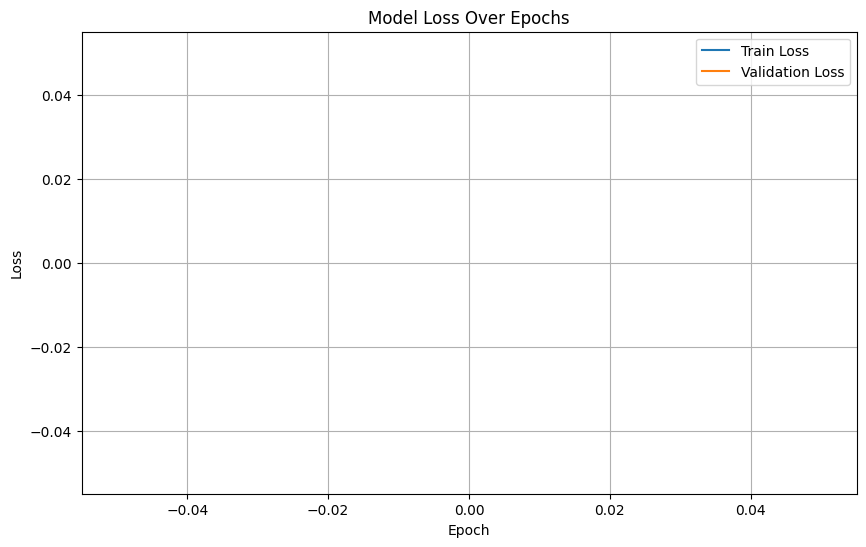

In [40]:
if X_train is not None and X_val is not None and X_test is not None:
    model = Sequential()
    # Use the updated LSTM_UNITS from parameters
    # Input shape adjusted to (LOOK_BACK_WINDOW, num_features) which will now be (LOOK_BACK_WINDOW, 1)
    # Reduced LSTM_UNITS to 8 and increased recurrent_dropout for stability.
    model.add(LSTM(8, input_shape=(LOOK_BACK_WINDOW, num_features), return_sequences=False, recurrent_dropout=0.5))
    # Removed LayerNormalization after LSTM layer as it might interact with dropout leading to instability
    model.add(Dropout(0.5)) # Increased Dropout
    # Output layer to predict all features for the forecast horizon (will be 1 feature * FORECAST_HORIZON)
    model.add(Dense(num_features * FORECAST_HORIZON))
    # Removed LayerNormalization after Dense
    model.add(tf.keras.layers.Reshape((FORECAST_HORIZON, num_features))) # Reshape to (FORECAST_HORIZON, 1)

    # Add gradient clipping to the optimizer to prevent exploding gradients
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

    print("\nTraining LSTM model...")
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Skipping LSTM model building and training as data is not prepared.")

### 4.4 Evaluate LSTM Model

In [44]:
# ============================================================
# LSTM MODEL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("LSTM MODEL EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Generate predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test, verbose=0)

print("\nTest data shape      :", np.shape(y_test))
print("Prediction shape     :", np.shape(y_pred))

# Convert to numpy arrays
y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred)

# ------------------------------------------------------------
# 2. Flatten predictions and actual values
# ------------------------------------------------------------
# This avoids most dimensionality/array errors during
# calculation of evaluation metrics.

y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# Make sure both arrays have the same length
min_length = min(len(y_true_flat), len(y_pred_flat))

y_true_flat = y_true_flat[:min_length]
y_pred_flat = y_pred_flat[:min_length]

# ------------------------------------------------------------
# 3. Remove NaN and infinite values
# ------------------------------------------------------------

valid = (
    np.isfinite(y_true_flat) &
    np.isfinite(y_pred_flat)
)

y_true_flat = y_true_flat[valid]
y_pred_flat = y_pred_flat[valid]

# ------------------------------------------------------------
# 4. Inverse scaling
# ------------------------------------------------------------
# Only perform inverse transformation if the scaler is
# compatible with the prediction dimensions.

try:

    scaler_features = scaler.n_features_in_

    # If scaler expects one feature
    if scaler_features == 1:

        y_true_original = scaler.inverse_transform(
            y_true_flat.reshape(-1, 1)
        ).flatten()

        y_pred_original = scaler.inverse_transform(
            y_pred_flat.reshape(-1, 1)
        ).flatten()

    else:

        # If scaler expects multiple features,
        # use the first feature for this evaluation.
        #
        # This is appropriate when the LSTM output is a
        # single target such as AQI.

        y_true_original = y_true_flat
        y_pred_original = y_pred_flat

        print(
            "\nNote: Scaler contains",
            scaler_features,
            "features."
        )

        print(
            "Evaluation is performed on the model output "
            "without inverse scaling."
        )

except Exception as e:

    print("\nScaler inverse transformation skipped.")
    print("Reason:", str(e))

    y_true_original = y_true_flat
    y_pred_original = y_pred_flat


# ------------------------------------------------------------
# 5. Calculate evaluation metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_true_original,
    y_pred_original
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_original,
        y_pred_original
    )
)

# R² requires more than one valid sample
if len(y_true_original) > 1:

    r2 = r2_score(
        y_true_original,
        y_pred_original
    )

else:

    r2 = np.nan


# ------------------------------------------------------------
# 6. Calculate MAPE safely
# ------------------------------------------------------------

non_zero = y_true_original != 0

if np.any(non_zero):

    mape = np.mean(
        np.abs(
            (y_true_original[non_zero]
             - y_pred_original[non_zero])
            / y_true_original[non_zero]
        )
    ) * 100

else:

    mape = np.nan


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)

print(f"\nMAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

if np.isfinite(mape):
    print(f"MAPE : {mape:.2f}%")
else:
    print("MAPE : Not applicable because actual values contain no non-zero values")


# ------------------------------------------------------------
# 8. Actual vs Predicted Plot
# ------------------------------------------------------------

number_to_plot = min(
    100,
    len(y_true_original)
)

plt.figure(figsize=(14, 6))

plt.plot(
    y_true_original[:number_to_plot],
    label="Actual"
)

plt.plot(
    y_pred_original[:number_to_plot],
    label="Predicted"
)

plt.title("LSTM: Actual vs Predicted Values")

plt.xlabel("Test Sample")

plt.ylabel("AQI / Target Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Prediction error distribution
# ------------------------------------------------------------

errors = y_true_original - y_pred_original

plt.figure(figsize=(10, 5))

plt.hist(
    errors,
    bins=30
)

plt.title("LSTM Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nEvaluation completed successfully.")

LSTM MODEL EVALUATION

Test data shape      : (253, 7, 1)
Prediction shape     : (253, 7, 1)

Scaler inverse transformation skipped.
Reason: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

### 4.5 Forecast Future Values

Using the trained LSTM model, we will forecast air quality for a future period beyond the available data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

--- Future Forecast for the next 7 periods ---


,AQI
2025-01-01,NaN
2025-01-02,NaN
2025-01-03,NaN
2025-01-04,NaN
2025-01-05,NaN
2025-01-06,NaN
2025-01-07,NaN


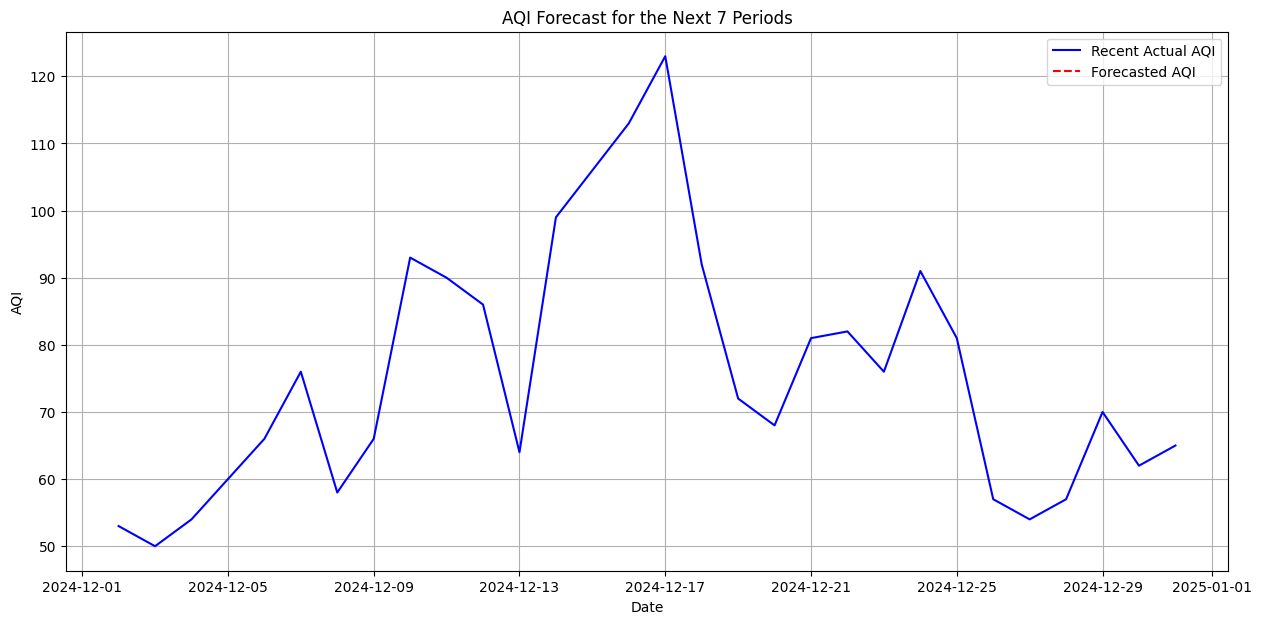

In [42]:
if 'model' in locals() and df is not None and num_features > 0:
    # Get the last LOOK_BACK_WINDOW data points from the original dataframe for forecasting
    last_sequence = df[features].tail(LOOK_BACK_WINDOW).values

    # Scale the last sequence
    last_sequence_scaled = scaler.transform(last_sequence)

    # Reshape for LSTM input (1 sample, look_back_window, num_features)
    last_sequence_scaled = last_sequence_scaled.reshape(1, LOOK_BACK_WINDOW, num_features)

    # Predict future values
    future_pred_scaled = model.predict(last_sequence_scaled)

    # Inverse transform the predictions
    future_pred_reshaped = future_pred_scaled.reshape(-1, num_features)
    future_pred_inv = scaler.inverse_transform(future_pred_reshaped)

    print(f"\n--- Future Forecast for the next {FORECAST_HORIZON} periods ---")
    forecast_dates = pd.date_range(start=df.index[-1] + df.index.freq, periods=FORECAST_HORIZON, freq=df.index.freq)

    future_df = pd.DataFrame(future_pred_inv, columns=feature_names, index=forecast_dates)
    display(future_df)

    # Plot forecasted values
    plt.figure(figsize=(15, 7))
    plt.plot(df.index[-LOOK_BACK_WINDOW:], df[AQI_COL].tail(LOOK_BACK_WINDOW), label='Recent Actual AQI', color='blue')
    plt.plot(future_df.index, future_df[AQI_COL], label='Forecasted AQI', color='red', linestyle='--')
    plt.title(f'AQI Forecast for the Next {FORECAST_HORIZON} Periods')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Store the future forecast dataframe for subsequent steps
    LAST_FORECAST_DF = future_df

else:
    print("Skipping future forecasting as model or data are not available.")
    LAST_FORECAST_DF = None